1. Загрузка и проверка датасетов
2. EDA и сравнение датасетов по признакам
3. Обучение/загрузка моделей (`DNN`, `MVE ensemble`, `SWAG`, `DUQ`, `BNN`)
4. In-domain и OOD оценка
5. Slice-анализ (`read` vs `write`) + статзначимость
6. Важность признаков для uncertainty
7. Эксперимент на merged-датасете

## Почему именно такой пайплайн

Чтобы показать benchmark-свойство для uncertainty, нужно одновременно доказать:
- **Domain shift**: разные поднаборы данных статистически отличаются.
- **Чувствительность моделей к shift**: в OOD падает качество.
- **Неопределенность полезна**: uncertainty меняется осмысленно и помогает локализовать сложные случаи.
- **Различимость моделей**: разные UQ-подходы ведут себя по-разному (калибровка, coverage, robustness).

Если все пункты выполняются, датасет можно аргументированно использовать как benchmark.


## DNN (Deterministic Baseline)

Dense neural Network (DNN) is a fully connected NN used as a deterministic baseline. It produces predictions and does not model predictive uncertainty (as DUQ)



## MVE (Mean-Variance Estimation)

Model predicts:

$$
(\mu(x), \sigma^2(x))
$$

Optimized via Gaussian NLL (более устойчивая к выбросам):

$$
NLL =
\frac{1}{N}\sum
\left[
\frac{(y_i-\mu_i)^2}{2\sigma_i^2}
+ \frac{1}{2}\log(2\pi\sigma_i^2)
\right]
$$

Captures aleatoric uncertainty.



## SWAG (Stochastic Weight Averaging Gaussian)

Approximates posterior over weights:

$$
w \sim \mathcal{N}(\bar w, \Sigma)
$$

Predictive uncertainty comes from weight sampling.
Primarily captures epistemic uncertainty.


## Bayesian Neural Networks (BNNs)

model uncertainty by placing a prior distribution over network weights and inferring a posterior distribution given the training data. Instead of learning a single point estimate of parameters, BNNs approximate the posterior p(w \mid \mathcal D).
The predictive distribution is obtained by marginalizing over weight uncertainty:

$ p(y \mid x, \mathcal D) = \int p(y \mid x, w)\, p(w \mid \mathcal D)\, dw. $

This formulation naturally induces the variance decomposition into aleatoric and epistemic components via the law of total variance. In practice, the integral is approximated using Monte Carlo sampling of weights from the posterior, enabling empirical estimation of predictive mean and epistemic uncertainty.

Unlike deterministic networks, BNNs provide a principled probabilistic framework for uncertainty estimation, directly corresponding to the theoretical decomposition of predictive variance.


## DUQ

DUQ (Deterministic Uncertainty Quantification) in the regression setting models uncertainty based on distances in a learned latent space. The input is mapped to a feature representation, and predictions are formed as a similarity-weighted combination of latent centroids. Predictive uncertainty is estimated via the distance to the nearest centroid, serving as a geometric proxy for epistemic uncertainty rather than a probabilistic variance decomposition


In [ ]:
import os
import math
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from models.dnn import train_simple_dnn, DNN
from models.mve import train_mve_ensemble, predict_mve_ensemble, MLP_MVE
from models.swag import predict_swag_model, make_model
from models.duq import DUQRegressor
from models.utils import get_device, fit_transform_dfs, SingleOutputDataset
from swa_gaussian.swag.posteriors import SWAG

warnings.filterwarnings("ignore")

import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr, norm
from waggon.surrogates.bnn import BNN

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cpu'
print("Device:", DEVICE)


Device: cpu


In [ ]:
# Config
TARGET = "lat"
CAT_COLS = ["load_type", "io_type", "raid", "device_type"]
NUM_COLS = ["iops", "block_size", "n_jobs", "iodepth", "read_fraction", "n_disks", "offset"]

DATASETS = {
    "hdd_sequential": {
        "train": "./dataset/hdd_sequential/train_hdd_sequential.csv",
        "test": "./dataset/hdd_sequential/test_hdd_sequential.csv",
        "device": "hdd",
        "pattern": "sequential",
    },
    "ssd_sequential": {
        "train": "./dataset/ssd_sequential/train_ssd_sequential.csv",
        "test": "./dataset/ssd_sequential/test_ssd_sequential.csv",
        "device": "ssd",
        "pattern": "sequential",
    },
    "ssd_random": {
        "train": "./dataset/ssd_random/train_ssd_random.csv",
        "test": "./dataset/ssd_random/test_ssd_random.csv",
        "device": "ssd",
        "pattern": "random",
    },
}

OUT_DIR = "./results/benchmark_all_in_one"
PLOT_DIR = os.path.join(OUT_DIR, "plots")
TABLE_DIR = os.path.join(OUT_DIR, "tables")
REPORT_DIR = os.path.join(OUT_DIR, "report")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

STATE_ROOT = "./states_benchmark_all"
os.makedirs(STATE_ROOT, exist_ok=True)

SAVE_PLOTS = True
LOAD_CACHED_PLOTS = True
TRAIN_IF_MISSING = True

# получены с помощью байесовской оптимизации из библиотеки hyperopt


PARAMS = {
    "dnn": {
      "batch_size": 64,
      "dropout": 0.014984047270350132,
      "epochs": 50,
      "h1": 96,
      "h2": 32,
      "lr": 0.0005991597204999438
    },
    "dnn_normalized": {
      "batch_size": 64,
      "dropout": 0.014984047270350132,
      "epochs": 50,
      "h1": 96,
      "h2": 32,
      "lr": 0.0005991597204999438
    },
    "mve_ensemble": {
      "batch_size": 128,
      "dropout": 0.011987237816280106,
      "ensemble_size": 5,
      "epochs": 30,
      "h1": 192,
      "h2": 64,
      "lr": 0.0005304458242135086
    },
    "swag": {
      "batch_size": 32,
      "lr": 0.0011619100004084193,
      "epochs": 120,
      "h1": 128,
      "h2": 64,
      "swag_start": 50
    },
    "duq": {
      "batch_size": 32,
      "epochs": 100,
      "latent_dim": 32,
      "lr": 0.000308059756922247,
      "n_centroids": 20
    }
  }



### 1. Вспомогательные функции


### Feature–Uncertainty & Feature–Target Relationships

Correlation between feature and target:

$$
\rho(x_j, y)
$$

Correlation between feature and predictive uncertainty:

$$
\rho(x_j, \sigma(x))
$$

If uncertainty correlates with specific features,
the dataset exhibits structured heteroscedasticity.


In [ ]:
# рисует изображение - это для кэшированных графиков
def show_image(path, figsize=(7,4)):
    img = plt.imread(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# вспом. функция для того чтобы узнать можно ли подгрузить график из кэша (сохраненный)
def save_or_show(path, figsize=(7,4)):
    if LOAD_CACHED_PLOTS and os.path.exists(path):
        show_image(path, figsize=figsize)
        return True
    return False

# получение словаря путей - тоже для сохранения, но уже моделей
def state_paths(dataset_name):
    base = os.path.join(STATE_ROOT, dataset_name)
    os.makedirs(base, exist_ok=True)
    return {
        "dnn": os.path.join(base, "dnn.pt"),
        "dnn_normalized": os.path.join(base, "dnn_normalized.pt"),
        "mve_ensemble": os.path.join(base, "mve_ensemble.pt"),
        "swag": os.path.join(base, "swag.pt"),
        "duq": os.path.join(base, "duq.pt"),
        "bnn": os.path.join(base, "bnn.pt"),
    }


def load_state(path):
    return torch.load(path, map_location="cpu")


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def safe_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if y_true.size == 0:
        return np.nan
    return rmse(y_true, y_pred)


def safe_mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if y_true.size == 0:
        return np.nan
    return mae(y_true, y_pred)


def unscale_y(y_scaled, y_scaler):
    y_scaled = np.asarray(y_scaled).reshape(-1, 1)
    return y_scaler.inverse_transform(y_scaled).reshape(-1)


def unscale_std(std_scaled, y_scaler):
    return np.asarray(std_scaled) * y_scaler.scale_[0]


def gaussian_nll(y, mu, std, eps=1e-6):
    std = np.clip(std, eps, None)
    var = std ** 2
    return float(np.mean(0.5 * np.log(2 * np.pi * var) + 0.5 * ((y - mu) ** 2) / var))

def z_from_alpha(alpha):
    table = {0.5: 0.674, 0.68: 1.0, 0.8: 1.282, 0.9: 1.645, 0.95: 1.96, 0.99: 2.576}
    if alpha in table:
        return table[alpha]
    ks = np.array(sorted(table.keys()))
    vs = np.array([table[k] for k in ks])
    return float(np.interp(alpha, ks, vs))


def coverage_and_width(y, mu, std, alpha=0.9):
    z = z_from_alpha(alpha)
    low = mu - z * std
    high = mu + z * std
    coverage = float(np.mean((y >= low) & (y <= high)))
    width = float(np.mean(high - low))
    return coverage, width


def spearman_corr(x, y):
    return float(spearmanr(x, y).correlation)


In [12]:
# SWAG with correct input dimension (fixes shape mismatch across OHE variants)
def train_swag_model_fixed(X_train_np, y_train_np, in_dim, hidden_dims=[128,64], lr=1e-3, epochs=120, swag_start=50, batch_size=64, device='cpu'):
    ds = torch.utils.data.TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train_np))
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

    def make():
        return make_model(in_dim)

    base_model = make()
    optimizer = torch.optim.Adam(base_model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()
    swag_model = SWAG(make, max_num_models=20)

    for ep in range(epochs):
        base_model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = base_model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
        if ep >= swag_start:
            swag_model.collect_model(base_model)

    return swag_model


In [13]:
def load_train_val_test(train_csv, test_csv, target_col=TARGET, cat_cols=CAT_COLS, val_frac=0.1, seed=42):
    df_train = pd.read_csv(train_csv)
    df_test = pd.read_csv(test_csv)
    df_train, df_val = train_test_split(df_train, test_size=val_frac, random_state=seed)

    X_tr, y_tr, X_val, y_val, X_test, y_test, feature_names, encs = fit_transform_dfs(
        df_train, df_val, df_test, target_col, cat_cols
    )

    train_ds = SingleOutputDataset(X_tr, y_tr, fit_scaler=False,
        x_scaler=encs["x_scaler"], y_scaler=encs["y_scaler"],
        original_df=df_train, feature_names=feature_names)
    val_ds = SingleOutputDataset(X_val, y_val, fit_scaler=False,
        x_scaler=encs["x_scaler"], y_scaler=encs["y_scaler"],
        original_df=df_val, feature_names=feature_names)
    test_ds = SingleOutputDataset(X_test, y_test, fit_scaler=False,
        x_scaler=encs["x_scaler"], y_scaler=encs["y_scaler"],
        original_df=df_test, feature_names=feature_names)

    return train_ds, val_ds, test_ds, encs


def build_dataset_with_encs(df, encs, target_col=TARGET):
    num_cols = encs["num_cols"]
    cat_cols = encs["cat_cols"]
    ohe = encs["ohe"]
    x_scaler = encs["x_scaler"]
    y_scaler = encs["y_scaler"]

    needed = num_cols + cat_cols + [target_col]
    df = df.dropna(subset=needed).reset_index(drop=True)

    if len(cat_cols) > 0:
        X_cat = ohe.transform(df[cat_cols].astype(str))
        cat_feature_names = [f"{col}__{cat}" for col, cats in zip(cat_cols, ohe.categories_) for cat in cats]
    else:
        X_cat = np.zeros((len(df), 0))
        cat_feature_names = []

    X_num = df[num_cols].values.astype(np.float32)
    X_raw = np.hstack([X_num, X_cat])
    y_raw = df[target_col].values.astype(np.float32)

    feature_names = num_cols + cat_feature_names
    ds = SingleOutputDataset(X_raw, y_raw, fit_scaler=False,
        x_scaler=x_scaler, y_scaler=y_scaler,
        original_df=df, feature_names=feature_names)
    return ds


## EDA: datasets as objects (before models)

Зачем эта часть: benchmark для uncertainty должен содержать реальные различия между доменами.
Если распределения очень похожи, OOD‑проверка теряет смысл.

In [ ]:
eda_frames = {}
for name, d in DATASETS.items():
    tr = pd.read_csv(d["train"])
    te = pd.read_csv(d["test"])
    df = pd.concat([tr, te], ignore_index=True)
    df["dataset"] = name
    df["device"] = d["device"]
    df["pattern"] = d["pattern"]
    eda_frames[name] = df

eda_all = pd.concat(list(eda_frames.values()), ignore_index=True)

summary = eda_all.groupby(["dataset", "device", "pattern"]).size().reset_index(name="count")
summary.to_csv(os.path.join(TABLE_DIR, "eda_dataset_sizes.csv"), index=False)
summary


,dataset,device,pattern,count
0,hdd_sequential,hdd,sequential,92130
1,ssd_random,ssd,random,121572
2,ssd_sequential,ssd,sequential,92142


In [ ]:
rows = []
for name, df in eda_frames.items():
    rows.append({
        "dataset": name,
        "rows": len(df),
        "duplicates": int(df.duplicated().sum()),
        "missing_total": int(df.isna().sum().sum()),
    })
eda_quality = pd.DataFrame(rows)
eda_quality.to_csv(os.path.join(TABLE_DIR, "eda_quality.csv"), index=False)
eda_quality


,dataset,rows,duplicates,missing_total
0,hdd_sequential,92130,58,0
1,ssd_sequential,92142,0,0
2,ssd_random,121572,0,0



# Exploratory Data Analysis (EDA)

We analyze marginal and joint distributions of features:

Marginal distribution:
$$
p(x_j)
$$

Joint distribution:
$$
p(x_j, x_k)
$$

Feature correlation matrix:

$$
\rho_{jk} =
\frac{\text{Cov}(x_j, x_k)}
{\sigma_j \sigma_k}
$$

EDA allows us to detect:

- Heterogeneity between domains
- Heavy-tailed or skewed distributions
- Potential sources of aleatoric uncertainty


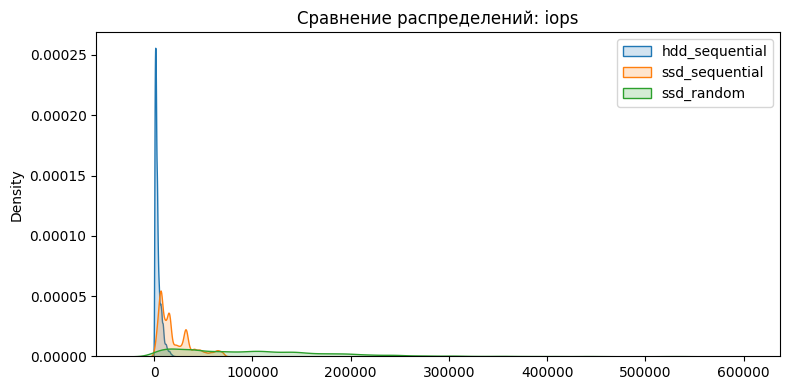

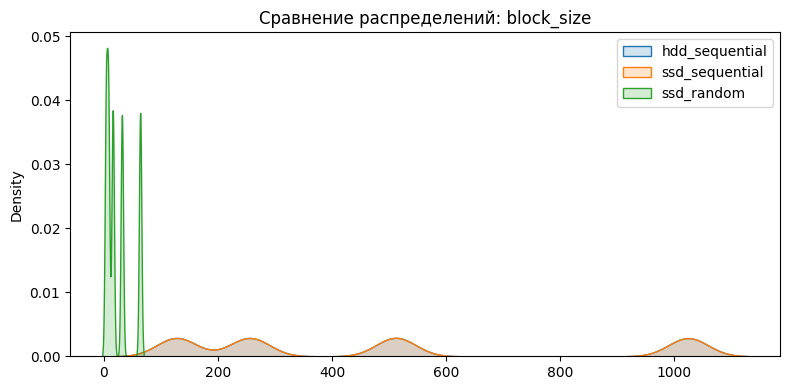

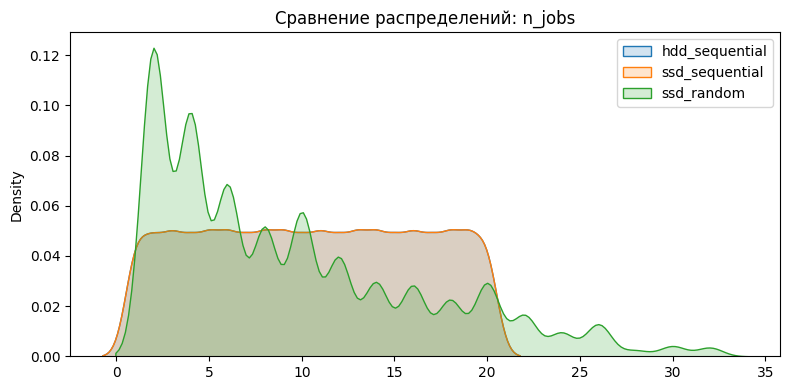

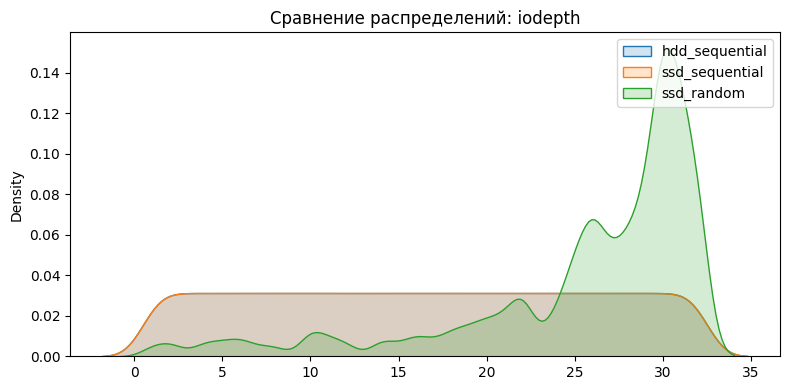

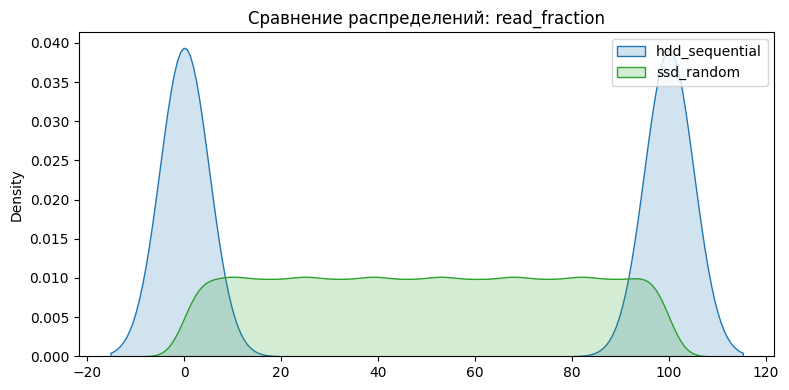

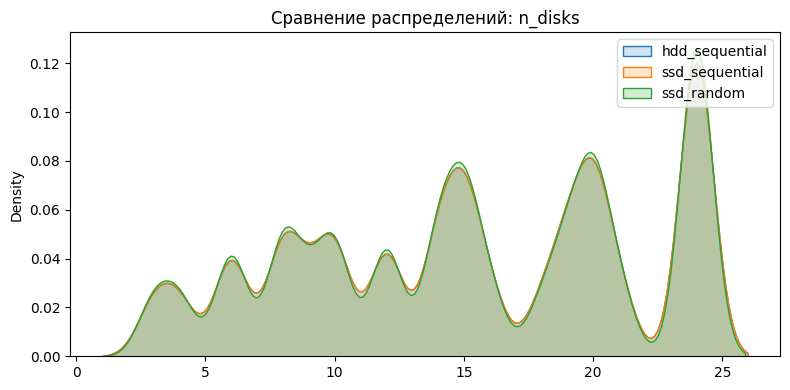

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


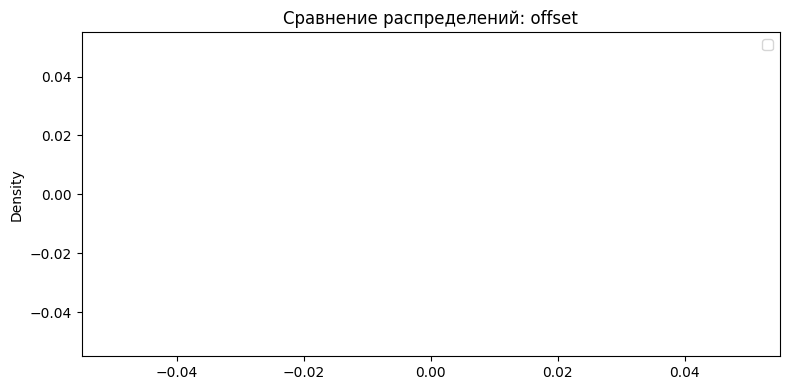

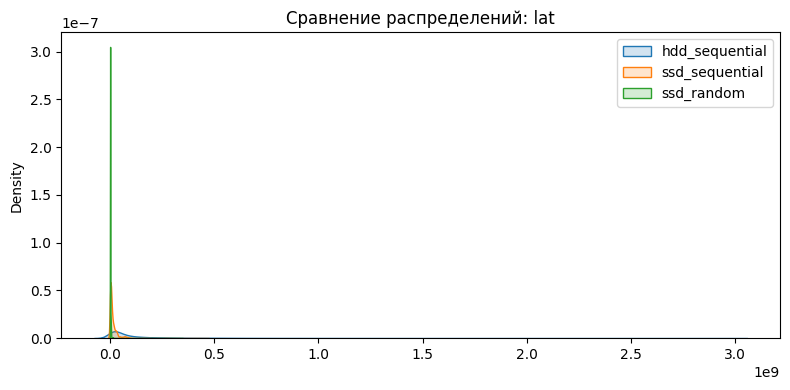

In [ ]:
for col in NUM_COLS + [TARGET]:
    path = os.path.join(PLOT_DIR, f"eda_dist_{col}.png")
    if save_or_show(path):
        continue

    plt.figure(figsize=(8,4))
    for name, df in eda_frames.items():
        vals = df[col].dropna().values
        sns.kdeplot(vals, label=name, fill=True, alpha=0.2)
        # else:
        #     plt.hist(vals, bins=60, alpha=0.3, label=name, density=True)
    plt.title(f"Сравнение распределений: {col}")
    plt.legend()
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()



# Domain Shift (Out-of-Distribution Evaluation)

We define:

- Source domain: $\mathcal{D}_S$
- Target domain: $\mathcal{D}_T$

Model is trained on:

$$
(x_i, y_i) \sim \mathcal{D}_S
$$

and evaluated on:

$$
(x_j, y_j) \sim \mathcal{D}_T
$$

If $\mathcal{D}_S \neq \mathcal{D}_T$, we expect:

1. Increase in prediction error:

$$
\Delta RMSE = RMSE_T - RMSE_S
$$

2. Increase in predictive uncertainty:

$$
\Delta \mathbb{E}[\sigma(x)]
=
\mathbb{E}_{x \sim \mathcal{D}_T}[\sigma(x)]
-
\mathbb{E}_{x \sim \mathcal{D}_S}[\sigma(x)]
$$

3. Strengthened uncertainty–error correlation:

$$
\rho_T > \rho_S
$$

If uncertainty grows under shift, the dataset stresses epistemic uncertainty.


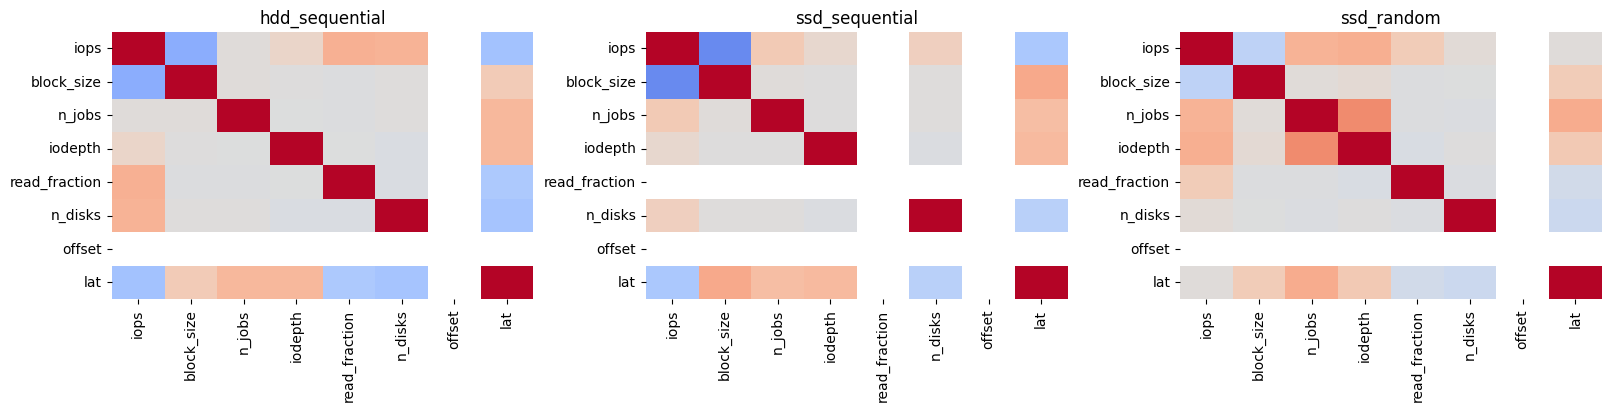

Вывод: если распределения/корреляции заметно различаются, это поддерживает тезис о domain shift и пригодности benchmark.


In [17]:
# Correlation: subplot side-by-side for all datasets
path = os.path.join(PLOT_DIR, "eda_corr_subplots.png")
if not save_or_show(path, figsize=(14,4)):
    fig, axes = plt.subplots(1, len(eda_frames), figsize=(16,4), constrained_layout=True)
    if len(eda_frames) == 1:
        axes = [axes]

    for ax, (name, df) in zip(axes, eda_frames.items()):
        corr = df[NUM_COLS + [TARGET]].corr()
        sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, cbar=False)
        # else:
        #     im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_title(name)

    if SAVE_PLOTS:
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

print("Вывод: если распределения/корреляции заметно различаются, это поддерживает тезис о domain shift и пригодности benchmark.")


In [18]:
# Statistical feature shift (pairwise, target + key numeric) - Regime shift is not artificially constructed; feature distributions differ statistically.
pairs = [
    ("hdd_sequential", "ssd_sequential"),
    ("hdd_sequential", "ssd_random"),
    ("ssd_sequential", "ssd_random"),
]

rows = []
for a, b in pairs:
    dfa = eda_frames[a]
    dfb = eda_frames[b]
    for col in NUM_COLS + [TARGET]:
        x = dfa[col].dropna().values
        y = dfb[col].dropna().values
        _, p = mannwhitneyu(x, y, alternative='two-sided')
        rows.append({
            "pair": f"{a} vs {b}",
            "feature": col,
            "pvalue": p,
        })

shift_df = pd.DataFrame(rows)
shift_df.to_csv(os.path.join(TABLE_DIR, "eda_feature_shift.csv"), index=False)
shift_df.head(20)


,pair,feature,pvalue
0,hdd_sequential vs ssd_sequential,iops,0.000000
1,hdd_sequential vs ssd_sequential,block_size,0.978327
2,hdd_sequential vs ssd_sequential,n_jobs,0.989331
3,hdd_sequential vs ssd_sequential,iodepth,0.975648
4,hdd_sequential vs ssd_sequential,read_fraction,0.000000
5,hdd_sequential vs ssd_sequential,n_disks,0.937781
6,hdd_sequential vs ssd_sequential,offset,1.000000
7,hdd_sequential vs ssd_sequential,lat,0.000000
8,hdd_sequential vs ssd_random,iops,0.000000
9,hdd_sequential vs ssd_random,block_size,0.000000


## Model training/loading

In [19]:
def train_model(model_type, params, train_ds, val_ds):
    if model_type in {"dnn", "dnn_normalized"}:
        m, _ = train_simple_dnn(
            train_ds=train_ds,
            val_ds=val_ds,
            hidden_dims=[params["h1"], params["h2"]],
            dropout=params["dropout"],
            lr=params["lr"],
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            device=DEVICE,
            verbose=False,
            use_spectral_norm=(model_type == "dnn_normalized"),
        )
        return m

    if model_type == "mve_ensemble":
        m, _ = train_mve_ensemble(
            train_ds=train_ds,
            val_ds=val_ds,
            ensemble_size=int(params["ensemble_size"]),
            hidden_dims=[params["h1"], params["h2"]],
            dropout=params["dropout"],
            lr=params["lr"],
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            device=DEVICE,
            verbose=False,
        )
        return m

    if model_type == "swag":
        X = train_ds.X.numpy()
        y = train_ds.y.numpy()
        return train_swag_model_fixed(
            X_train_np=X,
            y_train_np=y,
            in_dim=train_ds.X.shape[1],
            hidden_dims=[params["h1"], params["h2"]],
            lr=params["lr"],
            epochs=params["epochs"],
            swag_start=params["swag_start"],
            batch_size=params["batch_size"],
            device=str(DEVICE),
        )

    if model_type == "duq":
        m = DUQRegressor(
            input_dim=train_ds.X.shape[1],
            latent_dim=params.get("latent_dim", 8),
            n_centroids=params.get("n_centroids", 25),
        ).to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=params["lr"])
        losses = []
        for _ in range(params["epochs"]):
            m.train()
            run = 0.0
            for xb, yb in torch.utils.data.DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True):
                xb = xb.to(DEVICE); yb = yb.to(DEVICE)
                pred, unc = m(xb)
                loss = F.mse_loss(pred, yb) + 1e-4 * unc.mean()
                opt.zero_grad(); loss.backward(); opt.step()
                run += loss.item() * xb.size(0)
            losses.append(run / len(train_ds))
        m._epoch_losses = losses
        return m

    if model_type == "bnn":
        dev = "mps" if torch.backends.mps.is_available() else "cpu"
        surr = BNN(device=dev)
        surr.fit(train_ds.X.numpy(), train_ds.y.numpy().reshape(-1,1))
        return surr

    raise ValueError(model_type)


In [24]:
# Train/load per dataset
all_data = {}
all_models = {}

for dname, dcfg in DATASETS.items():
    print(f"\n[DATASET] {dname}")
    train_ds, val_ds, test_ds, encs = load_train_val_test(dcfg["train"], dcfg["test"])
    all_data[dname] = {"train": train_ds, "val": val_ds, "test": test_ds, "encs": encs}

    paths = state_paths(dname)
    models = {}

    # DNN
    model = None
    if os.path.exists(paths["dnn"]):
        ck = load_state(paths["dnn"])
        model = DNN(
            in_dim=train_ds.X.shape[1],
            hidden_dims=[ck.get("h1", 128), ck.get("h2", 64)],
            dropout=ck.get("dropout", 0.1),
            use_spectral_norm=ck.get("use_spectral_norm", False),
        ).to(DEVICE)
        model.load_state_dict(ck["state_dict"])
    elif TRAIN_IF_MISSING:
        model = train_model("dnn", PARAMS["dnn"], train_ds, val_ds)
        torch.save(
            {
                "state_dict": model.state_dict(),
                "h1": PARAMS["dnn"]["h1"],
                "h2": PARAMS["dnn"]["h2"],
                "dropout": PARAMS["dnn"]["dropout"],
                "use_spectral_norm": False,
            },
            paths["dnn"],
        )
    models["dnn"] = model

    # DNN normalized (spectral normalization)
    model = None
    if os.path.exists(paths["dnn_normalized"]):
        ck = load_state(paths["dnn_normalized"])
        model = DNN(
            in_dim=train_ds.X.shape[1],
            hidden_dims=[ck.get("h1", 128), ck.get("h2", 64)],
            dropout=ck.get("dropout", 0.1),
            use_spectral_norm=ck.get("use_spectral_norm", True),
        ).to(DEVICE)
        model.load_state_dict(ck["state_dict"])
    elif TRAIN_IF_MISSING:
        model = train_model("dnn_normalized", PARAMS["dnn_normalized"], train_ds, val_ds)
        torch.save(
            {
                "state_dict": model.state_dict(),
                "h1": PARAMS["dnn_normalized"]["h1"],
                "h2": PARAMS["dnn_normalized"]["h2"],
                "dropout": PARAMS["dnn_normalized"]["dropout"],
                "use_spectral_norm": True,
            },
            paths["dnn_normalized"],
        )
    models["dnn_normalized"] = model

    # MVE
    model = None
    if os.path.exists(paths["mve_ensemble"]):
        ck = load_state(paths["mve_ensemble"])
        h1, h2, dr = ck.get("h1",256), ck.get("h2",128), ck.get("dropout",0.1)
        ens = [MLP_MVE(train_ds.X.shape[1], hidden_dims=[h1,h2], dropout=dr).to(DEVICE) for _ in range(ck.get("ensemble_size",5))]
        for m, sd in zip(ens, ck["state_dicts"]):
            m.load_state_dict(sd)
        model = ens
    elif TRAIN_IF_MISSING:
        model = train_model("mve_ensemble", PARAMS["mve_ensemble"], train_ds, val_ds)
        torch.save({"state_dicts": [m.state_dict() for m in model], "h1": PARAMS["mve_ensemble"]["h1"], "h2": PARAMS["mve_ensemble"]["h2"], "dropout": PARAMS["mve_ensemble"]["dropout"], "ensemble_size": PARAMS["mve_ensemble"]["ensemble_size"]}, paths["mve_ensemble"])
    models["mve_ensemble"] = model

    # SWAG
    model = None
    if os.path.exists(paths["swag"]):
        ck = load_state(paths["swag"])
        in_dim_ck = ck.get("in_dim", train_ds.X.shape[1])
        swag = SWAG(lambda: make_model(in_dim_ck), max_num_models=20)
        swag.load_state_dict(ck["state_dict"])
        model = swag
    elif TRAIN_IF_MISSING:
        model = train_model("swag", PARAMS["swag"], train_ds, val_ds)
        torch.save({"state_dict": model.state_dict(), "in_dim": train_ds.X.shape[1]}, paths["swag"])
    models["swag"] = model

    # DUQ
    model = None
    if os.path.exists(paths["duq"]):
        ck = load_state(paths["duq"])
        model = DUQRegressor(input_dim=train_ds.X.shape[1], latent_dim=ck.get("latent_dim",64), n_centroids=ck.get("n_centroids",50)).to(DEVICE)
        model.load_state_dict(ck["state_dict"])
    elif TRAIN_IF_MISSING:
        model = train_model("duq", PARAMS["duq"], train_ds, val_ds)
        torch.save({"state_dict": model.state_dict(), "latent_dim": PARAMS["duq"]["latent_dim"], "n_centroids": PARAMS["duq"]["n_centroids"]}, paths["duq"])
    models["duq"] = model

    # BNN
    model = None
    try:
        model = train_model("bnn", PARAMS["dnn"], train_ds, val_ds)
        print('trained model bnn')
    except Exception as e:
        print(f"[WARN] Failed to train BNN for {dname}: {e}")
        model = None
    models["bnn"] = model

    all_models[dname] = models



[DATASET] hdd_sequential


100%|██████████| 100/100 [05:56<00:00,  3.57s/it]


trained model bnn

[DATASET] ssd_sequential


100%|██████████| 100/100 [06:28<00:00,  3.88s/it]


trained model bnn

[DATASET] ssd_random


100%|██████████| 100/100 [08:05<00:00,  4.86s/it]

trained model bnn


## Prediction and evaluation

In [25]:
def predict_dnn(model, ds):
    X = torch.tensor(ds.X.numpy(), device=DEVICE)
    with torch.no_grad():
        mu = model(X).cpu().numpy()
    return mu, None


def predict_mve(model, ds):
    mu, std, *_ = predict_mve_ensemble(model, ds.X.numpy(), device=DEVICE)
    return mu, std


def predict_swag(model, ds):
    X = torch.tensor(ds.X.numpy(), device=DEVICE)
    _, mu, std = predict_swag_model(model, X, n_samples=30, device=DEVICE)
    return mu, std


def predict_duq(model, ds):
    X = torch.tensor(ds.X.numpy(), device=DEVICE)
    with torch.no_grad():
        mu, unc = model(X)
    return mu.cpu().numpy(), unc.cpu().numpy()


def predict_bnn(model, ds):
    if model is None:
        return None, None
    X = ds.X.numpy()
    out = None
    if hasattr(model, "predict"):
        try:
            out = model.predict(X)
        except Exception:
            pass
    if out is None and hasattr(model, "model"):
        try:
            out = model.model(torch.tensor(X, dtype=torch.float32))
        except Exception:
            out = None
    if out is None:
        raise RuntimeError("BNN prediction failed")
    if isinstance(out, (tuple, list)) and len(out) >= 2:
        return np.asarray(out[0]), np.asarray(out[1])
    return np.asarray(out), None


def evaluate_models(models, ds, encs, label):
    y_true = unscale_y(ds.y.numpy(), encs["y_scaler"])
    rows = []

    for mname, model in models.items():
        if model is None:
            continue

        if mname in {"dnn", "dnn_normalized"}:
            mu_s, std_s = predict_dnn(model, ds)
            std_s = None
        elif mname == "mve_ensemble":
            mu_s, std_s = predict_mve(model, ds)
        elif mname == "swag":
            mu_s, std_s = predict_swag(model, ds)
        elif mname == "duq":
            mu_s, unc = predict_duq(model, ds)
            std_s = None
        elif mname == "bnn":
            mu_s, std_s = predict_bnn(model, ds)
        else:
            continue

        mu = unscale_y(mu_s, encs["y_scaler"])
        err = np.abs(y_true - mu)
        row = {
            "dataset": label,
            "model": mname,
            "rmse": rmse(y_true, mu),
            "mae": mae(y_true, mu),
        }

        if mname == "duq":
            row["unc_err_spearman"] = spearman_corr(err, unc)
        elif std_s is not None:
            std = unscale_std(std_s, encs["y_scaler"])
            row["nll"] = gaussian_nll(y_true, mu, std)
            # row["crps"] = gaussian_crps(y_true, mu, std)
            cov, width = coverage_and_width(y_true, mu, std, alpha=0.9)
            row["coverage_90"] = cov
            row["width_90"] = width
            row["unc_err_spearman"] = spearman_corr(err, std)

        rows.append(row)

    return pd.DataFrame(rows)


## In-domain results (per dataset)

In [26]:
in_rows = []
for dname, data in all_data.items():
    m = all_models[dname]
    df = evaluate_models(m, data["test"], data["encs"], label=f"{dname} (in-domain)")
    in_rows.append(df)

in_domain = pd.concat(in_rows, ignore_index=True)
in_domain.to_csv(os.path.join(TABLE_DIR, "in_domain_metrics.csv"), index=False)
in_domain


,dataset,model,rmse,mae,nll,coverage_90,width_90,unc_err_spearman
0,hdd_sequential (in-domain),dnn,9.540413e+07,4.102302e+07,NaN,NaN,NaN,NaN
1,hdd_sequential (in-domain),dnn_normalized,1.180240e+08,6.215462e+07,NaN,NaN,NaN,NaN
2,hdd_sequential (in-domain),mve_ensemble,8.714334e+07,3.403254e+07,18.539597,0.842829,1.361341e+08,0.791118
3,hdd_sequential (in-domain),swag,8.688774e+07,3.931134e+07,19.208317,0.881677,1.418506e+08,0.470364
4,hdd_sequential (in-domain),duq,9.971894e+07,4.073086e+07,NaN,NaN,NaN,-0.109501
5,hdd_sequential (in-domain),bnn,9.066212e+07,4.853552e+07,70.017807,0.336139,3.131835e+07,0.250703
6,ssd_sequential (in-domain),dnn,1.493743e+07,2.761760e+06,NaN,NaN,NaN,NaN
7,ssd_sequential (in-domain),dnn_normalized,1.062251e+07,5.056696e+06,NaN,NaN,NaN,NaN
8,ssd_sequential (in-domain),mve_ensemble,1.648681e+06,7.152025e+05,14.747769,0.887798,3.671742e+06,0.643007
9,ssd_sequential (in-domain),swag,1.483135e+07,2.970632e+06,15.803015,0.952746,8.658027e+06,0.631131


Benchmark должен различать модели по качеству. Если столбцы заметно различаются, набор не тривиален для uncertainty-моделей. Видно, что столбцы отмечаются и по порядку и по распределению.

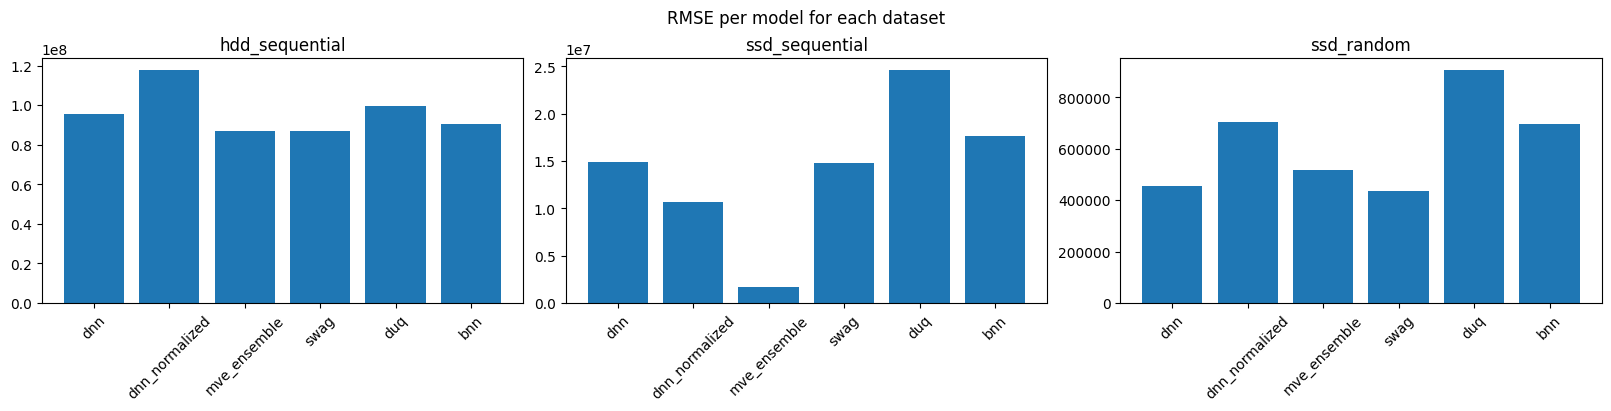

In [29]:
# Unified subplot: RMSE per model for each dataset
path = os.path.join(PLOT_DIR, "in_domain_rmse_subplots.png")
if not save_or_show(path, figsize=(14,4)):
    ds_names = list(DATASETS.keys())
    fig, axes = plt.subplots(1, len(ds_names), figsize=(16,4), constrained_layout=True)
    if len(ds_names) == 1:
        axes = [axes]

    for ax, dname in zip(axes, ds_names):
        sub = in_domain[in_domain["dataset"] == f"{dname} (in-domain)"]
        ax.bar(sub["model"], sub["rmse"])
        ax.set_title(dname)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle('RMSE per model for each dataset')
    if SAVE_PLOTS:
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()



## OOD evaluation (source -> target)

Здесь тестируем: модель, обученная на одном датасете, применяется к другому датасету через source-препроцессинг.
Это проверяет robustness и осмысленность uncertainty при сдвиге домена.

In [28]:
ood_parts = []
for src_name, src_data in all_data.items():
    src_models = all_models[src_name]
    src_encs = src_data["encs"]

    for tgt_name, dcfg in DATASETS.items():
        df_tgt = pd.read_csv(dcfg["test"])
        ds_tgt = build_dataset_with_encs(df_tgt, src_encs, TARGET)
        metrics = evaluate_models(src_models, ds_tgt, src_encs, label=f"{src_name} -> {tgt_name}")
        ood_parts.append(metrics)

ood = pd.concat(ood_parts, ignore_index=True)
ood.to_csv(os.path.join(TABLE_DIR, "ood_metrics.csv"), index=False)
ood.head(20)


,dataset,model,rmse,mae,nll,coverage_90,width_90,unc_err_spearman
0,hdd_sequential -> hdd_sequential,dnn,9.488466e+07,40788076.0,NaN,NaN,NaN,NaN
1,hdd_sequential -> hdd_sequential,dnn_normalized,1.176775e+08,61983840.0,NaN,NaN,NaN,NaN
2,hdd_sequential -> hdd_sequential,mve_ensemble,8.714334e+07,34032540.0,18.539597,0.842829,1.361341e+08,0.791118
3,hdd_sequential -> hdd_sequential,swag,8.790338e+07,40032512.0,19.289978,0.887828,1.482055e+08,0.551211
4,hdd_sequential -> hdd_sequential,duq,9.971894e+07,40730860.0,NaN,NaN,NaN,-0.109501
5,hdd_sequential -> hdd_sequential,bnn,9.006776e+07,48074584.0,73.197830,0.323352,2.946390e+07,0.174729
6,hdd_sequential -> ssd_sequential,dnn,9.534710e+07,60490336.0,NaN,NaN,NaN,NaN
7,hdd_sequential -> ssd_sequential,dnn_normalized,1.776801e+08,104139080.0,NaN,NaN,NaN,NaN
8,hdd_sequential -> ssd_sequential,mve_ensemble,2.263489e+07,14430269.0,18.819445,0.595372,2.856231e+07,0.714994
9,hdd_sequential -> ssd_sequential,swag,2.064873e+08,146362384.0,19.975508,0.895782,3.664724e+08,0.899615


Benchmark-сценарий подтверждается, если по диагонали (in-domain) ошибки ниже, чем вне диагонали (OOD), и это проявляется по-разному у моделей.

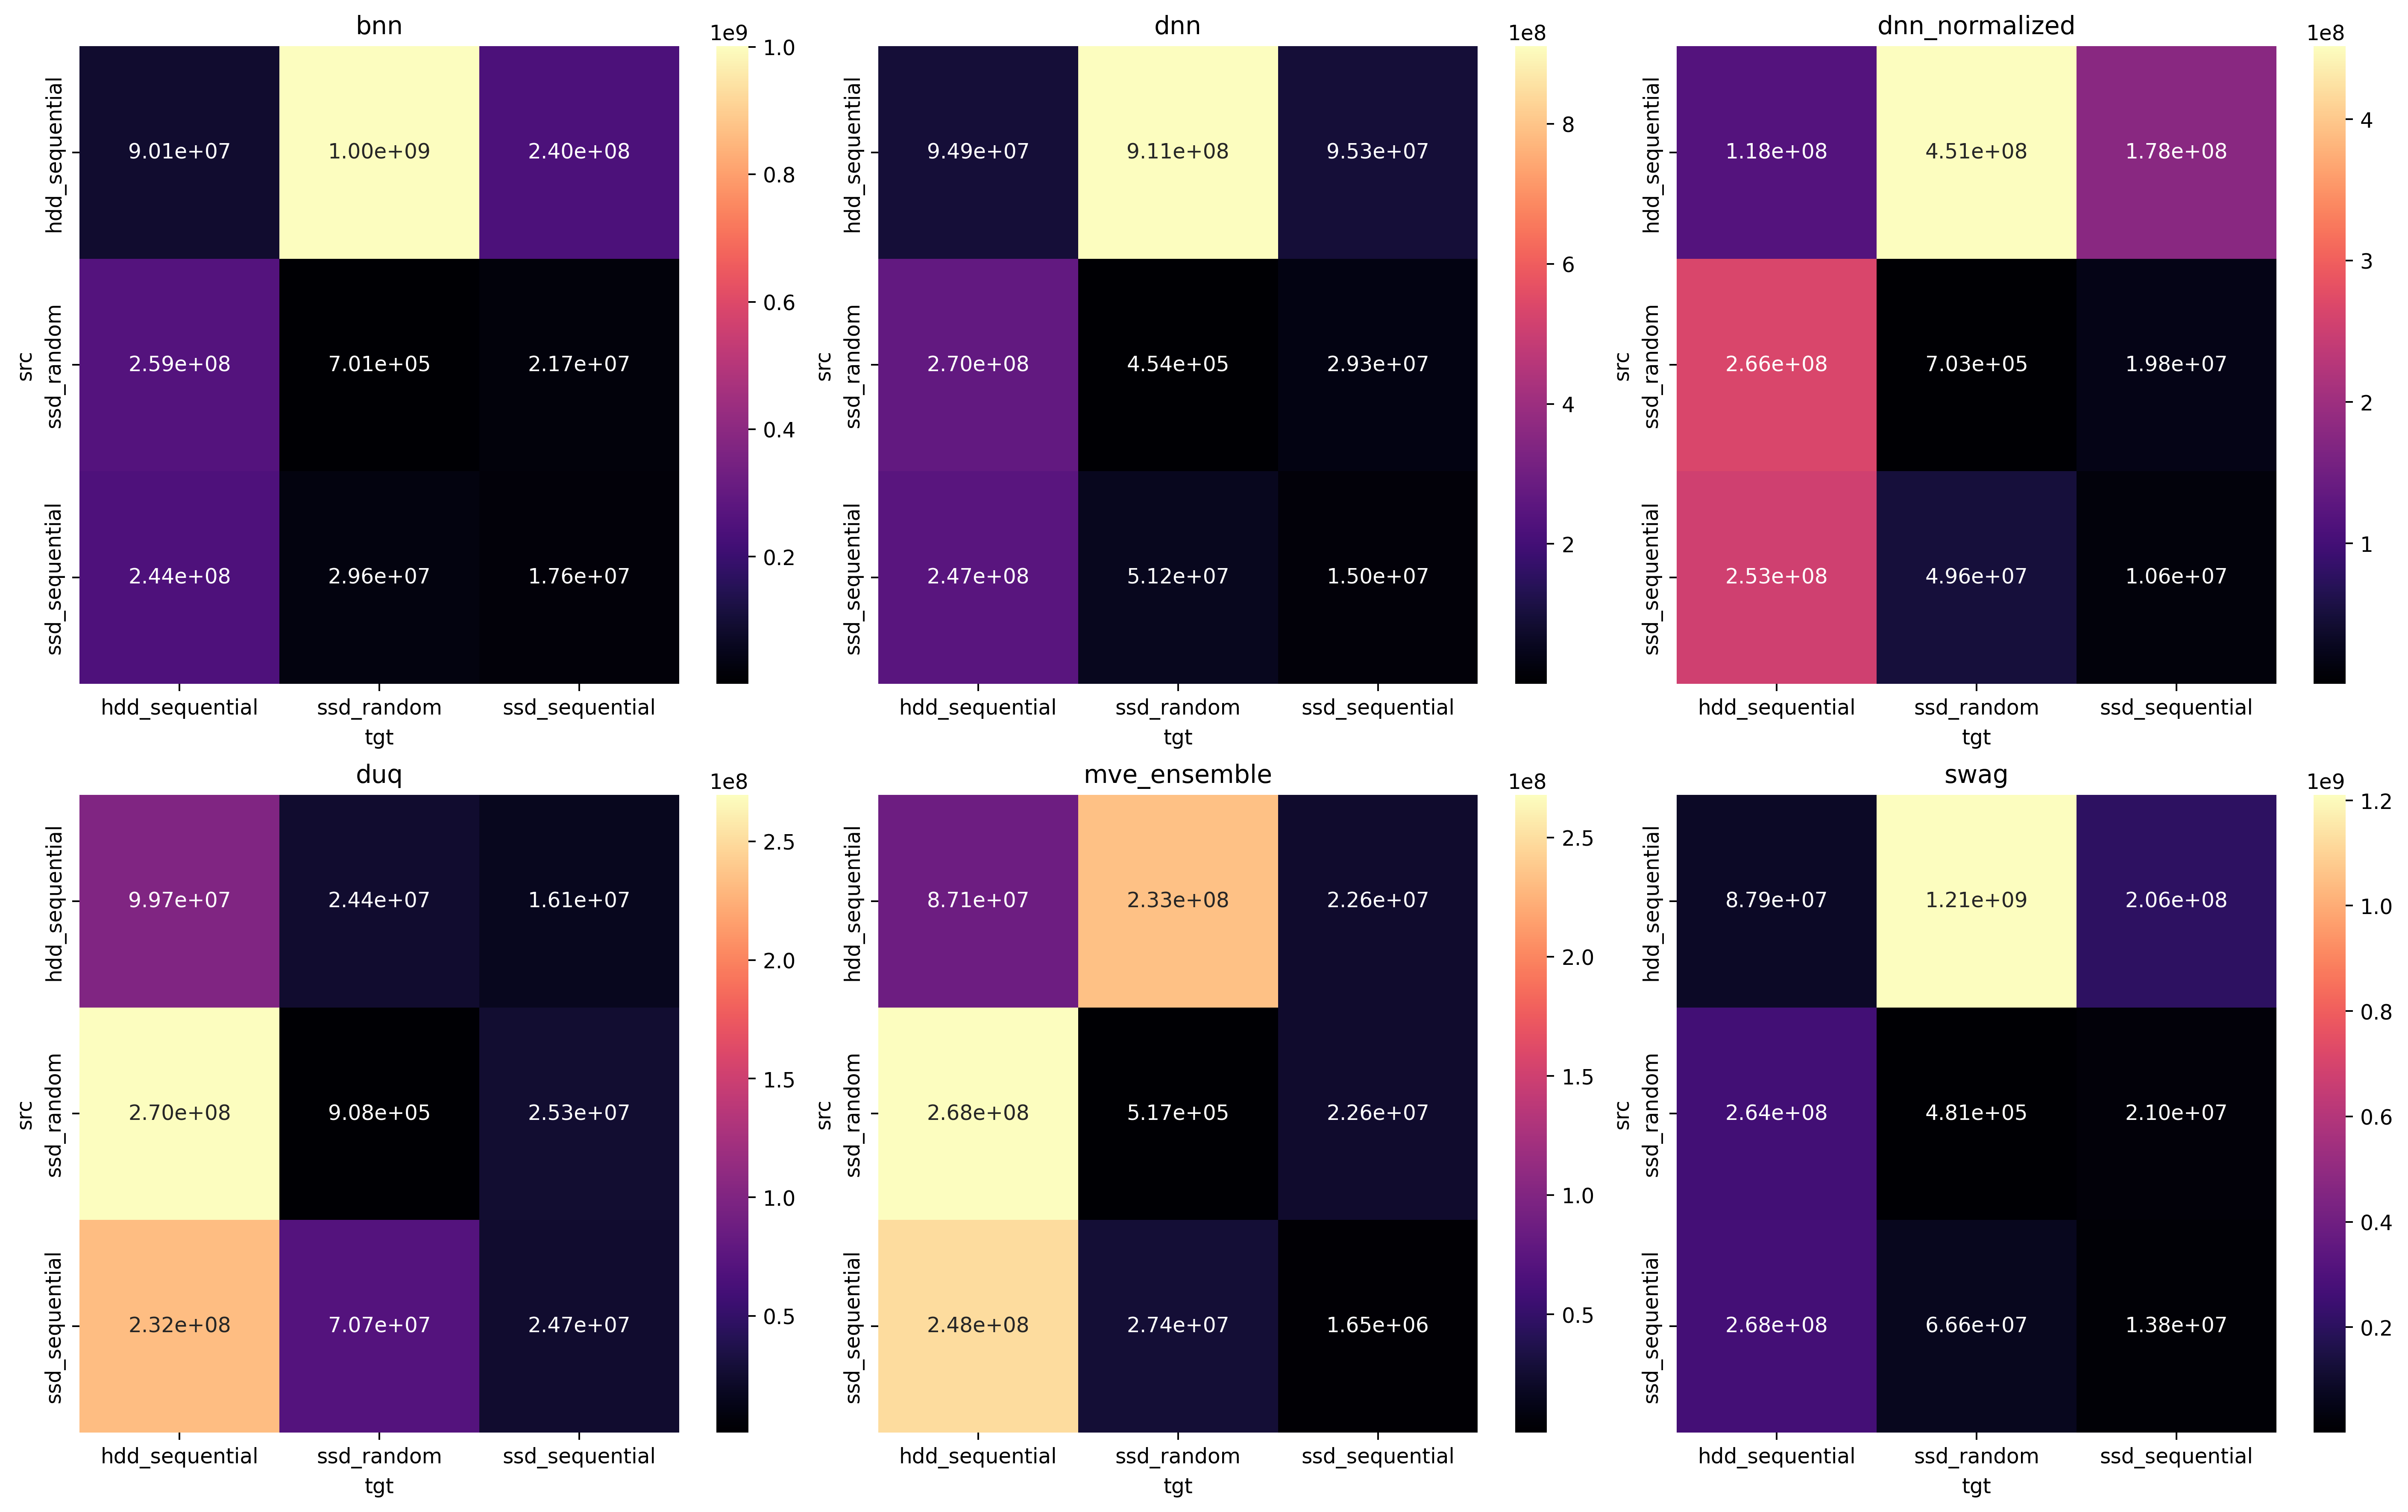

In [31]:
# Heatmap per model: OOD RMSE matrix (src x tgt)
models_for_heat = sorted(ood["model"].unique())
path = os.path.join(PLOT_DIR, "ood_rmse_heatmaps_by_model.png")
if not save_or_show(path, figsize=(14,8)):
    fig, axes = plt.subplots(2, 3, figsize=(16,10), constrained_layout=True,  dpi=350)
    axes = axes.ravel()

    for i, mname in enumerate(models_for_heat):
        ax = axes[i]
        sub = ood[ood["model"] == mname].copy()
        sub["src"] = sub["dataset"].str.split(" -> ").str[0]
        sub["tgt"] = sub["dataset"].str.split(" -> ").str[1]
        piv = sub.pivot(index="src", columns="tgt", values="rmse")
        sns.heatmap(piv, annot=True, fmt=".2e", cmap="magma", ax=ax)
        # else:
        #     im = ax.imshow(piv.values, cmap="magma")
        #     ax.set_xticks(range(len(piv.columns)))
        #     ax.set_xticklabels(piv.columns, rotation=45, ha='right')
        #     ax.set_yticks(range(len(piv.index)))
        #     ax.set_yticklabels(piv.index)
        ax.set_title(mname)

    for j in range(len(models_for_heat), len(axes)):
        axes[j].axis('off')

    if SAVE_PLOTS:
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


In [32]:
# OOD degradation summary
tmp = ood.copy()
tmp["src"] = tmp["dataset"].str.split(" -> ").str[0]
tmp["tgt"] = tmp["dataset"].str.split(" -> ").str[1]
tmp["is_ood"] = tmp["src"] != tmp["tgt"]

deg = tmp.groupby(["model", "is_ood"]) ["rmse"].mean().reset_index()
deg.to_csv(os.path.join(TABLE_DIR, "ood_degradation_summary.csv"), index=False)
deg

# TODO: эксп форма записи чисел

,model,is_ood,rmse
0,bnn,False,36126932.0
1,bnn,True,299154528.0
2,dnn,False,36762884.0
3,dnn,True,267224560.0
4,dnn_normalized,False,42997308.0
5,dnn_normalized,True,202923648.0
6,duq,False,41760852.0
7,duq,True,106316256.0
8,mve_ensemble,False,29769786.0
9,mve_ensemble,True,136976624.0


## Read vs Write slice analysis

Почему это важно: benchmark для uncertainty должен уметь выявлять “сложные режимы” внутри домена, не только между доменами.

In [33]:
rw_rows = []
for dname, data in all_data.items():
    ds = data["test"]
    encs = data["encs"]
    meta = ds.original_df.reset_index(drop=True)

    mask = None
    if "io_type" in meta.columns:
        mask = meta["io_type"].astype(str).str.lower().str.contains("read")
    elif "read_fraction" in meta.columns:
        mask = meta["read_fraction"] >= 50

    if mask is None:
        continue
    mask = mask.values[:len(ds)]

    y_true = unscale_y(ds.y.numpy(), encs["y_scaler"])

    for mname, model in all_models[dname].items():
        if model is None:
            continue

        if mname in {"dnn", "dnn_normalized"}:
            mu_s, std_s = predict_dnn(model, ds)
            std_s = None
        elif mname == "mve_ensemble":
            mu_s, std_s = predict_mve(model, ds)
        elif mname == "swag":
            mu_s, std_s = predict_swag(model, ds)
        elif mname == "duq":
            mu_s, unc = predict_duq(model, ds)
            std_s = None
        elif mname == "bnn":
            mu_s, std_s = predict_bnn(model, ds)
        else:
            continue

        mu = unscale_y(mu_s, encs["y_scaler"])
        n_read = int(mask.sum()); n_write = int((~mask).sum())
        rw_rows.append({"dataset": dname, "model": mname, "split": "read", "n": n_read, "rmse": safe_rmse(y_true[mask], mu[mask]), "mae": safe_mae(y_true[mask], mu[mask])})
        rw_rows.append({"dataset": dname, "model": mname, "split": "write", "n": n_write, "rmse": safe_rmse(y_true[~mask], mu[~mask]), "mae": safe_mae(y_true[~mask], mu[~mask])})

        if mname == "duq":
            uu = unc
            rw_rows.append({"dataset": dname, "model": mname, "split": "read_unc", "mean_unc": float(np.mean(uu[mask]))})
            rw_rows.append({"dataset": dname, "model": mname, "split": "write_unc", "mean_unc": float(np.mean(uu[~mask]))})
        elif std_s is not None:
            uu = unscale_std(std_s, encs["y_scaler"])
            rw_rows.append({"dataset": dname, "model": mname, "split": "read_unc", "mean_unc": float(np.mean(uu[mask]))})
            rw_rows.append({"dataset": dname, "model": mname, "split": "write_unc", "mean_unc": float(np.mean(uu[~mask]))})

rw = pd.DataFrame(rw_rows)
rw.to_csv(os.path.join(TABLE_DIR, "read_write_summary_all.csv"), index=False)
rw.head(30)


,dataset,model,split,n,rmse,mae,mean_unc
0,hdd_sequential,dnn,read,9360.0,3.443840e+07,14297577.0,NaN
1,hdd_sequential,dnn,write,9174.0,1.306422e+08,68059920.0,NaN
2,hdd_sequential,dnn_normalized,read,9360.0,6.936578e+07,29291216.0,NaN
3,hdd_sequential,dnn_normalized,write,9174.0,1.514611e+08,95530616.0,NaN
4,hdd_sequential,mve_ensemble,read,9360.0,3.043156e+07,9596373.0,NaN
5,hdd_sequential,mve_ensemble,write,9174.0,1.199876e+08,58964140.0,NaN
6,hdd_sequential,mve_ensemble,read_unc,NaN,NaN,NaN,8.428072e+06
7,hdd_sequential,mve_ensemble,write_unc,NaN,NaN,NaN,7.499630e+07
8,hdd_sequential,swag,read,9360.0,3.607548e+07,18913596.0,NaN
9,hdd_sequential,swag,write,9174.0,1.188210e+08,61058112.0,NaN


Если read/write систематически разделяются по ошибке и uncertainty, это усиливает benchmark-кейс как стресс-тест режимов нагрузки.

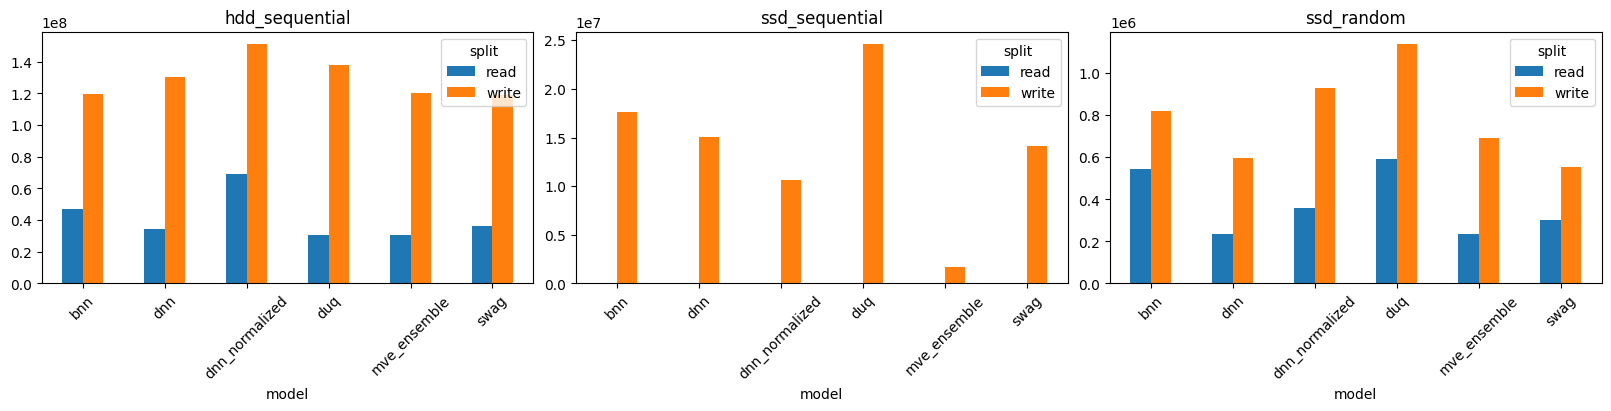

In [34]:
# Subplots: read vs write RMSE by model for each dataset
path = os.path.join(PLOT_DIR, "rw_rmse_subplots.png")
if not save_or_show(path, figsize=(14,4)):
    ds_names = list(DATASETS.keys())
    fig, axes = plt.subplots(1, len(ds_names), figsize=(16,4), constrained_layout=True)
    if len(ds_names) == 1:
        axes = [axes]

    for ax, dname in zip(axes, ds_names):
        sub = rw[(rw["dataset"] == dname) & (rw["split"].isin(["read", "write"]))]
        piv = sub.pivot(index="model", columns="split", values="rmse")
        piv.plot(kind="bar", ax=ax)
        ax.set_title(dname)
        ax.tick_params(axis='x', rotation=45)

    if SAVE_PLOTS:
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


In [35]:
# Significance: read vs write for error and uncertainty per dataset/model
sig_rows = []
for dname, data in all_data.items():
    ds = data["test"]
    encs = data["encs"]
    meta = ds.original_df.reset_index(drop=True)

    mask = None
    if "io_type" in meta.columns:
        mask = meta["io_type"].astype(str).str.lower().str.contains("read")
    elif "read_fraction" in meta.columns:
        mask = meta["read_fraction"] >= 50
    if mask is None:
        continue
    mask = mask.values[:len(ds)]

    y_true = unscale_y(ds.y.numpy(), encs["y_scaler"])

    for mname, model in all_models[dname].items():
        if model is None:
            continue

        if mname in {"dnn", "dnn_normalized"}:
            mu_s, std_s = predict_dnn(model, ds)
            std_s = None
        elif mname == "mve_ensemble":
            mu_s, std_s = predict_mve(model, ds)
        elif mname == "swag":
            mu_s, std_s = predict_swag(model, ds)
        elif mname == "duq":
            mu_s, unc = predict_duq(model, ds)
            std_s = None
        elif mname == "bnn":
            mu_s, std_s = predict_bnn(model, ds)
        else:
            continue

        mu = unscale_y(mu_s, encs["y_scaler"])
        err = np.abs(y_true - mu)

        if not np.any(mask):
            continue
            sig_rows.append({"dataset": dname, "model": mname, "metric": "error", "pvalue": np.nan})
            sig_rows.append({"dataset": dname, "model": mname, "metric": "uncertainty", "pvalue": np.nan})
            continue
        
        _, p = mannwhitneyu(err[mask], err[~mask], alternative='two-sided')
        sig_rows.append({"dataset": dname, "model": mname, "metric": "error", "pvalue": p})

        if mname == "duq":
            u = unc
        elif std_s is not None:
            u = unscale_std(std_s, encs["y_scaler"])
        else:
            continue

        _, p = mannwhitneyu(u[mask], u[~mask], alternative='two-sided')
        sig_rows.append({"dataset": dname, "model": mname, "metric": "uncertainty", "pvalue": p})

sig_df = pd.DataFrame(sig_rows)

sig_df.to_csv(os.path.join(TABLE_DIR, "rw_significance_all.csv"), index=False)
strong = sig_df[sig_df["pvalue"] < 0.05]
strong.to_csv(os.path.join(TABLE_DIR, "rw_significance_strong_all.csv"), index=False)

sig_df.head(20), strong.head(20)


(           dataset           model       metric         pvalue
 0   hdd_sequential             dnn        error   0.000000e+00
 1   hdd_sequential  dnn_normalized        error   0.000000e+00
 2   hdd_sequential    mve_ensemble        error   0.000000e+00
 3   hdd_sequential    mve_ensemble  uncertainty   0.000000e+00
 4   hdd_sequential            swag        error   0.000000e+00
 5   hdd_sequential            swag  uncertainty  1.283352e-219
 6   hdd_sequential             duq        error   0.000000e+00
 7   hdd_sequential             duq  uncertainty   1.386271e-01
 8   hdd_sequential             bnn        error   0.000000e+00
 9   hdd_sequential             bnn  uncertainty  5.643606e-127
 10      ssd_random             dnn        error   5.967678e-14
 11      ssd_random  dnn_normalized        error  9.160294e-182
 12      ssd_random    mve_ensemble        error   1.971652e-07
 13      ssd_random    mve_ensemble  uncertainty  4.935248e-105
 14      ssd_random            swag     

## Uncertainty feature importance (correlation-based)

Пояснение: корреляция `feature ↔ uncertainty` не доказывает причинность, но показывает, какие признаки системно связаны с ростом uncertainty.
Если топ-фичи меняются между датасетами и моделями, это еще один признак нетривиального benchmark.

In [36]:
TOP_K = 12
fi_rows = []

for dname, data in all_data.items():
    ds = data["test"]
    encs = data["encs"]
    feat_names = ds.feature_names if ds.feature_names is not None else [f"f{i}" for i in range(ds.X.shape[1])]
    X = ds.X.numpy()

    for mname, model in all_models[dname].items():
        if model is None:
            continue

        if mname == "mve_ensemble":
            _, std = predict_mve(model, ds)
            unc = unscale_std(std, encs["y_scaler"])
        elif mname == "swag":
            _, std = predict_swag(model, ds)
            unc = unscale_std(std, encs["y_scaler"])
        elif mname == "duq":
            _, unc = predict_duq(model, ds)
        elif mname == "bnn":
            _, std = predict_bnn(model, ds)
            if std is None:
                continue
            unc = unscale_std(std, encs["y_scaler"])
        else:
            continue

        corrs = []
        for j in range(X.shape[1]):
            xj = X[:, j]
            if np.std(xj) == 0:
                corrs.append(0.0)
            else:
                corrs.append(float(np.corrcoef(xj, unc)[0, 1]))
        corrs = np.array(corrs)
        order = np.argsort(np.abs(corrs))[::-1][:TOP_K]

        for rank, j in enumerate(order, start=1):
            fi_rows.append({
                "dataset": dname,
                "model": mname,
                "feature": feat_names[j],
                "corr": corrs[j],
                "abs_corr": abs(corrs[j]),
                "rank": rank,
            })

fi_df = pd.DataFrame(fi_rows)
fi_df.to_csv(os.path.join(TABLE_DIR, "feature_importance_unc_topk.csv"), index=False)
fi_df.head(30)


,dataset,model,feature,corr,abs_corr,rank
0,hdd_sequential,mve_ensemble,n_disks,-0.452857,0.452857,1
1,hdd_sequential,mve_ensemble,io_type__read,-0.357288,0.357288,2
2,hdd_sequential,mve_ensemble,io_type__write,0.357288,0.357288,3
3,hdd_sequential,mve_ensemble,read_fraction,-0.357288,0.357288,4
4,hdd_sequential,mve_ensemble,iops,-0.302829,0.302829,5
5,hdd_sequential,mve_ensemble,iodepth,0.218272,0.218272,6
6,hdd_sequential,mve_ensemble,raid__2+1,0.179114,0.179114,7
7,hdd_sequential,mve_ensemble,block_size,-0.136606,0.136606,8
8,hdd_sequential,mve_ensemble,raid__4+2,-0.134931,0.134931,9
9,hdd_sequential,mve_ensemble,raid__8+2,-0.116845,0.116845,10


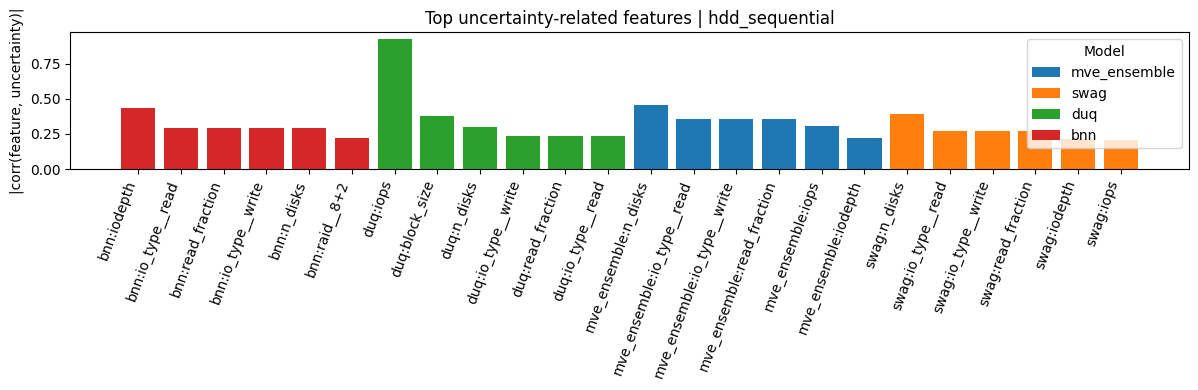

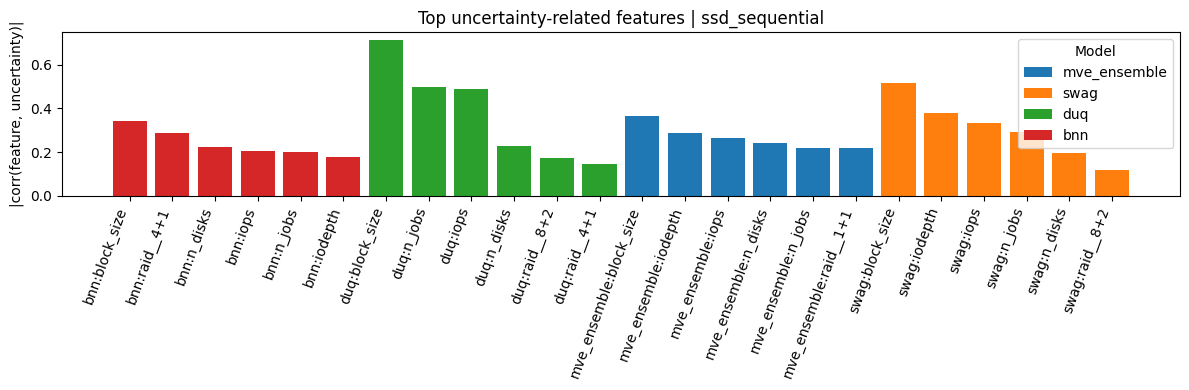

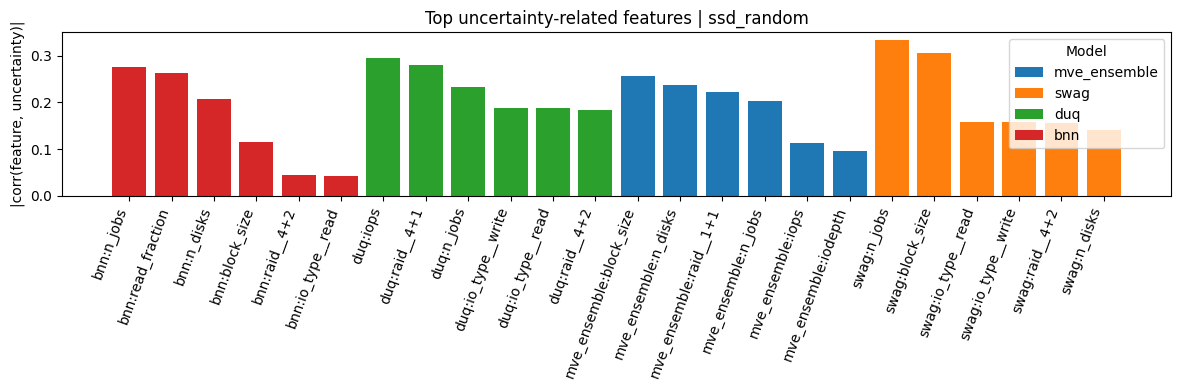

Вывод: смена топ-фич между датасетами/моделями показывает, что benchmark чувствителен к различным механизмам uncertainty.


In [38]:
# Unified comparison plot: top feature abs(corr) by model (per dataset)
from matplotlib.patches import Patch

MODEL_CMAP = {
    "mve_ensemble": "tab:blue",
    "swag": "tab:orange",
    "duq": "tab:green",
    "bnn": "tab:red",
}

for dname in DATASETS.keys():
    path = os.path.join(PLOT_DIR, f"fi_unc_{dname}.png")
    if save_or_show(path, figsize=(12,4)):
        continue

    sub = fi_df[(fi_df["dataset"] == dname) & (fi_df["rank"] <= 6)]
    if sub.empty:
        continue

    plt.figure(figsize=(12,4))
    labels = []
    vals = []
    colors = []

    for m in sorted(sub["model"].unique()):
        sm = sub[sub["model"] == m].sort_values("rank")
        for _, r in sm.iterrows():
            labels.append(f"{m}:{r['feature']}")
            vals.append(r["abs_corr"])
            colors.append(MODEL_CMAP.get(m, "gray"))

    plt.bar(range(len(vals)), vals, color=colors)
    plt.xticks(range(len(vals)), labels, rotation=70, ha='right')
    plt.ylabel("|corr(feature, uncertainty)|")
    plt.title(f"Top uncertainty-related features | {dname}")

    legend_handles = [Patch(facecolor=color, label=model) for model, color in MODEL_CMAP.items()]
    plt.legend(handles=legend_handles, title="Model", loc="upper right")

    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

print("Вывод: смена топ-фич между датасетами/моделями показывает, что benchmark чувствителен к различным механизмам uncertainty.")


## Merged dataset experiment

Зачем: проверить, как ведут себя модели при обучении на общей смеси доменов и как они обобщают на каждый поддомен.

In [39]:
# Build merged frame
parts = []
for dname, dcfg in DATASETS.items():
    tr = pd.read_csv(dcfg["train"])
    te = pd.read_csv(dcfg["test"])
    tr["dataset"] = dname
    te["dataset"] = dname
    parts.extend([tr, te])

merged_df = pd.concat(parts, ignore_index=True)

tr_df, tmp_df = train_test_split(merged_df, test_size=0.2, random_state=SEED)
va_df, te_df = train_test_split(tmp_df, test_size=0.5, random_state=SEED)

X_tr, y_tr, X_va, y_va, X_te, y_te, feat, encs_m = fit_transform_dfs(tr_df, va_df, te_df, TARGET, CAT_COLS)
train_m = SingleOutputDataset(X_tr, y_tr, fit_scaler=False, x_scaler=encs_m["x_scaler"], y_scaler=encs_m["y_scaler"], original_df=tr_df, feature_names=feat)
val_m = SingleOutputDataset(X_va, y_va, fit_scaler=False, x_scaler=encs_m["x_scaler"], y_scaler=encs_m["y_scaler"], original_df=va_df, feature_names=feat)
test_m = SingleOutputDataset(X_te, y_te, fit_scaler=False, x_scaler=encs_m["x_scaler"], y_scaler=encs_m["y_scaler"], original_df=te_df, feature_names=feat)

# train/load merged models
m_paths = state_paths("merged_all")
merged_models = {}

# DNN
m = None
if os.path.exists(m_paths["dnn"]):
    ck = load_state(m_paths["dnn"])
    m = DNN(
        in_dim=train_m.X.shape[1],
        hidden_dims=[ck.get("h1",128), ck.get("h2",64)],
        dropout=ck.get("dropout",0.1),
        use_spectral_norm=ck.get("use_spectral_norm", False),
    ).to(DEVICE)
    m.load_state_dict(ck["state_dict"])
elif TRAIN_IF_MISSING:
    m = train_model("dnn", PARAMS["dnn"], train_m, val_m)
    torch.save({"state_dict": m.state_dict(), "h1": PARAMS["dnn"]["h1"], "h2": PARAMS["dnn"]["h2"], "dropout": PARAMS["dnn"]["dropout"], "use_spectral_norm": False}, m_paths["dnn"])
merged_models["dnn"] = m

# DNN normalized
m = None
if os.path.exists(m_paths["dnn_normalized"]):
    ck = load_state(m_paths["dnn_normalized"])
    m = DNN(
        in_dim=train_m.X.shape[1],
        hidden_dims=[ck.get("h1",128), ck.get("h2",64)],
        dropout=ck.get("dropout",0.1),
        use_spectral_norm=ck.get("use_spectral_norm", True),
    ).to(DEVICE)
    m.load_state_dict(ck["state_dict"])
elif TRAIN_IF_MISSING:
    m = train_model("dnn_normalized", PARAMS["dnn_normalized"], train_m, val_m)
    torch.save({"state_dict": m.state_dict(), "h1": PARAMS["dnn_normalized"]["h1"], "h2": PARAMS["dnn_normalized"]["h2"], "dropout": PARAMS["dnn_normalized"]["dropout"], "use_spectral_norm": True}, m_paths["dnn_normalized"])
merged_models["dnn_normalized"] = m

# MVE
m = None
if os.path.exists(m_paths["mve_ensemble"]):
    ck = load_state(m_paths["mve_ensemble"])
    h1, h2, dr = ck.get("h1",256), ck.get("h2",128), ck.get("dropout",0.1)
    ens = [MLP_MVE(train_m.X.shape[1], hidden_dims=[h1,h2], dropout=dr).to(DEVICE) for _ in range(ck.get("ensemble_size",5))]
    for mm, sd in zip(ens, ck["state_dicts"]):
        mm.load_state_dict(sd)
    m = ens
elif TRAIN_IF_MISSING:
    m = train_model("mve_ensemble", PARAMS["mve_ensemble"], train_m, val_m)
    torch.save({"state_dicts": [mm.state_dict() for mm in m], "h1": PARAMS["mve_ensemble"]["h1"], "h2": PARAMS["mve_ensemble"]["h2"], "dropout": PARAMS["mve_ensemble"]["dropout"], "ensemble_size": PARAMS["mve_ensemble"]["ensemble_size"]}, m_paths["mve_ensemble"])
merged_models["mve_ensemble"] = m

merged_metrics = evaluate_models(merged_models, test_m, encs_m, label="merged_all")
merged_metrics.to_csv(os.path.join(TABLE_DIR, "merged_metrics.csv"), index=False)
merged_metrics


100%|██████████| 5/5 [07:22<00:00, 88.46s/it]


,dataset,model,rmse,mae,nll,coverage_90,width_90,unc_err_spearman
0,merged_all,dnn,39244100.0,9317749.0,NaN,NaN,NaN,NaN
1,merged_all,dnn_normalized,92416456.0,25376606.0,NaN,NaN,NaN,NaN
2,merged_all,mve_ensemble,47910692.0,8818031.0,14.684476,0.942227,41009024.0,0.675227


In [40]:
# Evaluate merged models on each original dataset using merged encoders
sub_rows = []
for dname, dcfg in DATASETS.items():
    df = pd.read_csv(dcfg["test"])
    ds = build_dataset_with_encs(df, encs_m, TARGET)
    part = evaluate_models(merged_models, ds, encs_m, label=f"merged -> {dname}")
    sub_rows.append(part)

merged_sub = pd.concat(sub_rows, ignore_index=True)
merged_sub.to_csv(os.path.join(TABLE_DIR, "merged_subset_metrics.csv"), index=False)
merged_sub


,dataset,model,rmse,mae,nll,coverage_90,width_90,unc_err_spearman
0,merged -> hdd_sequential,dnn,7.354698e+07,2.910196e+07,NaN,NaN,NaN,NaN
1,merged -> hdd_sequential,dnn_normalized,1.375869e+08,6.937276e+07,NaN,NaN,NaN,NaN
2,merged -> hdd_sequential,mve_ensemble,7.384906e+07,2.758922e+07,17.621635,0.955056,1.393810e+08,0.859999
3,merged -> ssd_sequential,dnn,2.776276e+06,1.751932e+06,NaN,NaN,NaN,NaN
4,merged -> ssd_sequential,dnn_normalized,2.300391e+07,1.263952e+07,NaN,NaN,NaN,NaN
5,merged -> ssd_sequential,mve_ensemble,1.465050e+06,3.551389e+05,13.917136,0.990128,3.008424e+06,0.619722
6,merged -> ssd_random,dnn,1.549370e+06,1.251553e+06,NaN,NaN,NaN,NaN
7,merged -> ssd_random,dnn_normalized,5.626626e+06,2.914146e+06,NaN,NaN,NaN,NaN
8,merged -> ssd_random,mve_ensemble,1.786516e+05,8.979154e+04,13.013801,0.911044,4.438757e+05,-0.145926


In [43]:
import torch
import torch.nn as nn
import pandas as pd

def linear_sigmas(linear: nn.Linear):
    W = linear.weight.detach()
    W = W.float().cpu()
    s = torch.linalg.svdvals(W) # сингулярные значения
    return float(s.max()), float(s.min())

def model_layer_sigmas(model: nn.Module):
    rows = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear):
            smax, smin = linear_sigmas(m)
            rows.append({
                "layer": name,
                "shape": tuple(m.weight.shape),
                "sigma_max": smax,
                "sigma_min": smin,
                "cond_approx": (smax / (smin + 1e-12)),
            })
    return pd.DataFrame(rows)

In [44]:
base_name = next(iter(DATASETS.keys()))
dnn = all_models[base_name]["dnn"]
dnn_normalized = all_models[base_name]["dnn_normalized"]

print(f"Dataset for layer sigma check: {base_name}")
display(model_layer_sigmas(dnn).assign(model="dnn"))
display(model_layer_sigmas(dnn_normalized).assign(model="dnn_normalized"))


Dataset for layer sigma check: hdd_sequential


,layer,shape,sigma_max,sigma_min,cond_approx,model
0,net.0,"(96, 17)",4.278338,0.823753,5.193712,dnn
1,net.3,"(32, 96)",7.324877,0.355029,20.631797,dnn
2,net.6,"(1, 32)",1.382566,1.382566,1.000000,dnn


,layer,shape,sigma_max,sigma_min,cond_approx,model
0,net.0,"(96, 17)",1.039913,0.260588,3.990647,dnn_normalized
1,net.3,"(32, 96)",1.001431,0.116005,8.632627,dnn_normalized
2,net.6,"(1, 32)",1.000000,1.000000,1.000000,dnn_normalized


In [45]:
for d in all_models.keys():
    print(f"\n{d}: dnn")
    display(model_layer_sigmas(all_models[d]["dnn"]))
    print(f"{d}: dnn_normalized")
    display(model_layer_sigmas(all_models[d]["dnn_normalized"]))



hdd_sequential: dnn


,layer,shape,sigma_max,sigma_min,cond_approx
0,net.0,"(96, 17)",4.278338,0.823753,5.193712
1,net.3,"(32, 96)",7.324877,0.355029,20.631797
2,net.6,"(1, 32)",1.382566,1.382566,1.000000


hdd_sequential: dnn_normalized


,layer,shape,sigma_max,sigma_min,cond_approx
0,net.0,"(96, 17)",1.037665,0.260024,3.990647
1,net.3,"(32, 96)",1.001106,0.115968,8.632631
2,net.6,"(1, 32)",1.000000,1.000000,1.000000



ssd_sequential: dnn


...

,layer,shape,sigma_max,sigma_min,cond_approx
0,net.0,"(96, 16)",1.005565,0.181385,5.543819
1,net.3,"(32, 96)",1.014363,0.097328,10.422098
2,net.6,"(1, 32)",1.000000,1.000000,1.000000



ssd_random: dnn


,layer,shape,sigma_max,sigma_min,cond_approx
0,net.0,"(96, 17)",5.062272,1.000076,5.061885
1,net.3,"(32, 96)",14.297215,0.397145,35.999948
2,net.6,"(1, 32)",2.129452,2.129452,1.000000


ssd_random: dnn_normalized


,layer,shape,sigma_max,sigma_min,cond_approx
0,net.0,"(96, 17)",1.042312,0.320740,3.249713
1,net.3,"(32, 96)",1.002595,0.113782,8.811543
2,net.6,"(1, 32)",1.000000,1.000000,1.000000


In [ ]:
for dname in DATASETS:
    p = state_paths(dname)
    print(
        dname,
        "dnn_ckpt=", os.path.exists(p["dnn"]),
        "dnn_normalized_ckpt=", os.path.exists(p["dnn_normalized"]),
    )


hdd_sequential dnn_ckpt= True dnn_normalized_ckpt= True
ssd_sequential dnn_ckpt= True dnn_normalized_ckpt= True
ssd_random dnn_ckpt= True dnn_normalized_ckpt= True


In [47]:
cond_rows = []
for d in all_models.keys():
    dnn_cond = float(model_layer_sigmas(all_models[d]["dnn"])["cond_approx"].mean())
    dnn_norm_cond = float(model_layer_sigmas(all_models[d]["dnn_normalized"])["cond_approx"].mean())
    cond_rows.append({
        "dataset": d,
        "dnn_cond_mean": dnn_cond,
        "dnn_normalized_cond_mean": dnn_norm_cond,
        "ratio_dnn_over_norm": dnn_cond / dnn_norm_cond if dnn_norm_cond > 0 else np.nan,
    })

cond_df = pd.DataFrame(cond_rows)
cond_df


,dataset,dnn_cond_mean,dnn_normalized_cond_mean,ratio_dnn_over_norm
0,hdd_sequential,8.941836,4.541092,1.969094
1,ssd_sequential,10.937244,5.655306,1.933979
2,ssd_random,14.020611,4.353752,3.220351


In [48]:
for d in all_models.keys():
    print(f"\n{d} - dnn_normalized")
    print(model_layer_sigmas(all_models[d]["dnn_normalized"]))



hdd_sequential - dnn_normalized
   layer     shape  sigma_max  sigma_min  cond_approx
0  net.0  (96, 17)   1.032111   0.258633     3.990646
1  net.3  (32, 96)   1.000659   0.115916     8.632628
2  net.6   (1, 32)   1.000000   1.000000     1.000000

ssd_sequential - dnn_normalized
   layer     shape  sigma_max  sigma_min  cond_approx
0  net.0  (96, 16)   1.003806   0.181068     5.543818
1  net.3  (32, 96)   1.007043   0.096626    10.422101
2  net.6   (1, 32)   1.000000   1.000000     1.000000

ssd_random - dnn_normalized
   layer     shape  sigma_max  sigma_min  cond_approx
0  net.0  (96, 17)   1.042312   0.320740     3.249713
1  net.3  (32, 96)   1.002595   0.113782     8.811543
2  net.6   (1, 32)   1.000000   1.000000     1.000000


In [ ]:
def sensitivity_dnn(model: nn.Module, X: torch.Tensor, batch_size: int = 512, device=None) -> torch.Tensor:
    device = device or next(model.parameters()).device
    model.eval()

    sens_all = []
    for i in range(0, X.shape[0], batch_size):
        xb = X[i:i+batch_size].to(device).detach().requires_grad_(True)

        y = model(xb)
        if y.ndim > 1:
            y = y.squeeze(-1)

        g = torch.autograd.grad(outputs=y.sum(), inputs=xb, create_graph=False, retain_graph=False)[0]
        s = g.norm(dim=1)
        sens_all.append(s.detach().cpu())

    return torch.cat(sens_all, dim=0)


[DATASET] hdd_sequential

[DATASET] ssd_sequential

[DATASET] ssd_random


Text(0.5, 0.98, 'ID sensitivity: dnn vs dnn_normalized')

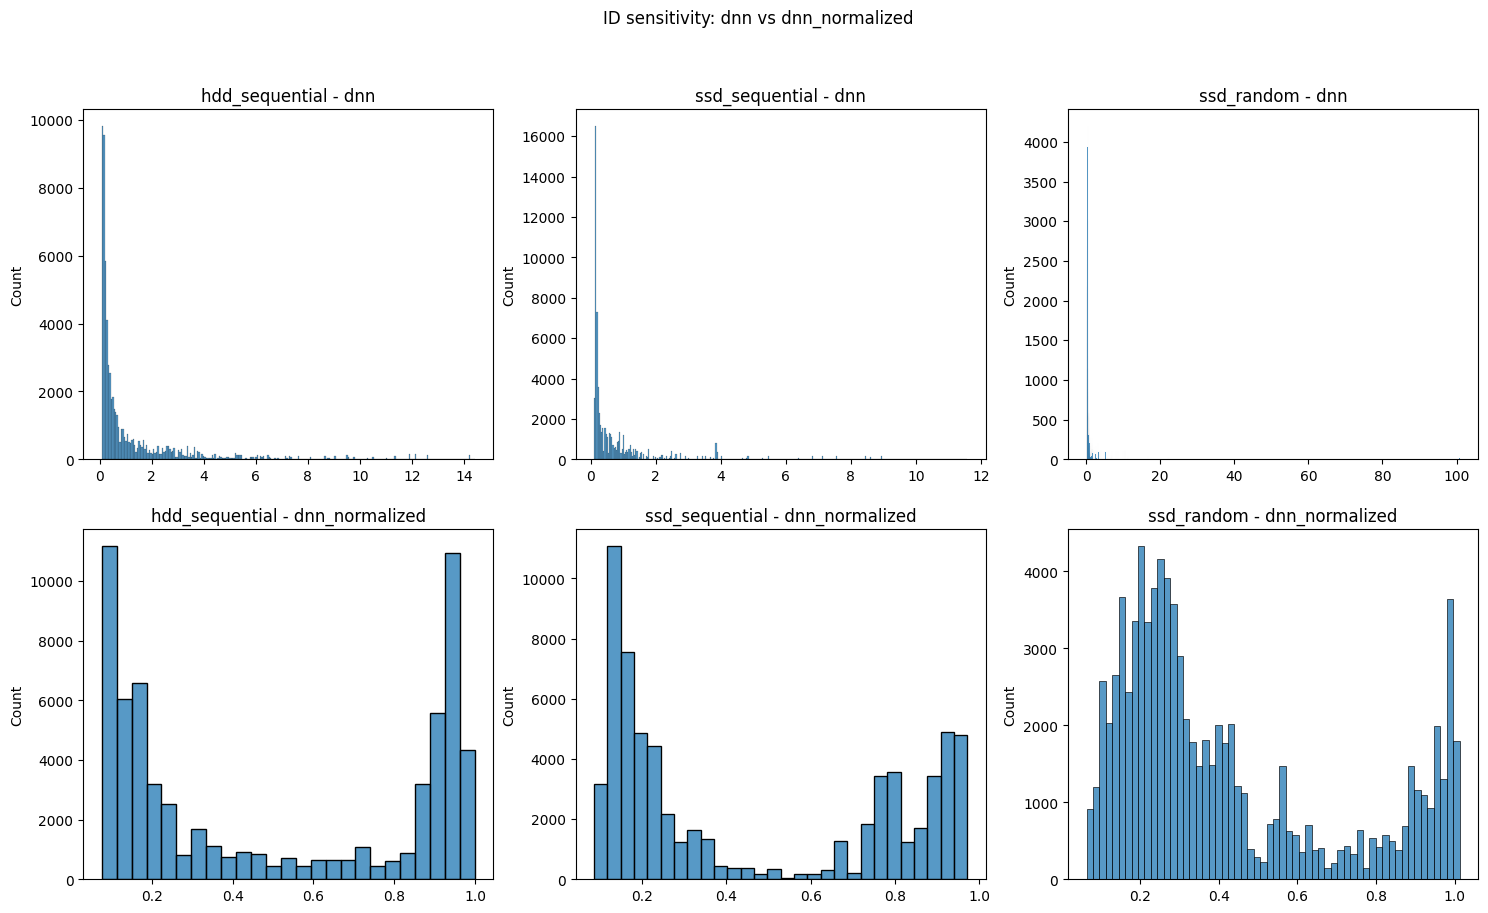

In [50]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
i = 0
for dname, dcfg in DATASETS.items():
    print(f"\n[DATASET] {dname}")
    train_ds = all_data[dname]['train']

    sns.histplot(sensitivity_dnn(all_models[dname]['dnn_normalized'], train_ds.X), ax=ax[1, i])
    sns.histplot(sensitivity_dnn(all_models[dname]['dnn'], train_ds.X), ax=ax[0, i])
    ax[1, i].set_title(f'{dname} - dnn_normalized')
    ax[0, i].set_title(f'{dname} - dnn')

    i += 1
plt.suptitle('ID sensitivity: dnn vs dnn_normalized')


In [51]:
dnames = list(DATASETS.keys())
sens_id = sensitivity_dnn(all_models[dnames[0]]['dnn_normalized'], all_data[dnames[0]]['train'].X).numpy()
# sens_ood1 = sensitivity_dnn(all_models[dnames[0]]['dnn_normalized'], all_data[dnames[1]]['train'].X).numpy()
sens_ood = sensitivity_dnn(all_models[dnames[0]]['dnn_normalized'], all_data[dnames[2]]['train'].X).numpy()


In [52]:
import numpy as np
from sklearn.metrics import roc_auc_score

# sens_id, sens_ood — numpy arrays
scores = np.concatenate([sens_id, sens_ood])
labels = np.concatenate([np.zeros_like(sens_id), np.ones_like(sens_ood)])  # 1 = OOD

auroc = roc_auc_score(labels, scores)
print("AUROC (OOD detection via sensitivity):", auroc)

AUROC (OOD detection via sensitivity): 0.5140277068346708


In [53]:
mu_pred, _ = predict_dnn(all_models[dnames[0]]['dnn_normalized'], all_data[dnames[0]]['train'])
y_true = all_data[dnames[0]]['train'].y.numpy()
sens = sensitivity_dnn(all_models[dnames[0]]['dnn_normalized'], all_data[dnames[0]]['train'].X).numpy()


In [54]:
mu_pred[:5]


array([-0.486257  , -0.02629105,  0.49289408,  0.09545548, -0.14452457],
      dtype=float32)

In [55]:
import pandas as pd

def spearman_corr(a, b):
    a = pd.Series(a).rank().to_numpy()
    b = pd.Series(b).rank().to_numpy()
    return float(np.corrcoef(a, b)[0,1])

corr = spearman_corr(np.abs(y_true - mu_pred), sens)
print("Spearman(|error|, sensitivity):", corr)


Spearman(|error|, sensitivity): 0.7581221178582778


<Axes: ylabel='Count'>

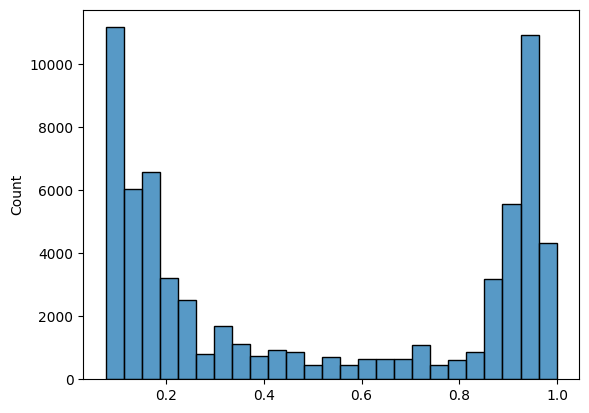

In [56]:
d = list(DATASETS.keys())[0]
train_ds = all_data[d]['train']
sns.histplot(sensitivity_dnn(all_models[d]['dnn_normalized'], train_ds.X))
